# Skeleton-Based Shoplifting Detection via Pose Estimation and Temporal Hybrid Models

*Privacy-preserving CCTV analysis using YOLO pose estimation, LSTM with attention, and ensemble methods*

---

This project builds a complete ML pipeline that detects shoplifting from CCTV footage using only
skeleton keypoints — no appearance data stored, fully privacy-preserving. A systematic
experimental process across 4 rounds and 25+ configurations improved F1 from a 0.393 majority
baseline to **0.895** (weighted LSTM+RF ensemble), a **+127% relative gain**.

In [1]:
import numpy as np
import pickle
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\malho\Desktop\claudeagent\RETAILPROJECT")
FEATURE_DIR = BASE_DIR / "v10_Features"
RESULTS_DIR = BASE_DIR / "v10_Results"

# Load all results
with open(RESULTS_DIR / "all_results.pkl", "rb") as f:
    phase2_results = pickle.load(f)
with open(RESULTS_DIR / "v11_results.pkl", "rb") as f:
    r12_data = pickle.load(f)
with open(RESULTS_DIR / "v11_r3_results.pkl", "rb") as f:
    r3_data = pickle.load(f)
with open(RESULTS_DIR / "v11_r4_results.pkl", "rb") as f:
    r4_data = pickle.load(f)

# Hero Results Table
r4 = r4_data["ensemble_result"]
baseline_f1 = 0.3934
improvement = (r4["f1_mean"] - baseline_f1) / baseline_f1 * 100

print("=" * 48)
print("  FINAL RESULTS: Weighted LSTM + RF Ensemble")
print("=" * 48)
print(f"  F1 Score:    {r4['f1_mean']:.3f} +/- {r4['f1_std']:.3f}")
print(f"  AUC-ROC:     {r4['auc_mean']:.3f} +/- {r4['auc_std']:.3f}")
print(f"  Precision:   {r4['precision_mean']:.3f}")
print(f"  Recall:      {r4['recall_mean']:.3f}")
print(f"  FP / FN:     {r4['fp_count']} / {r4['fn_count']}")
print("-" * 48)
print(f"  Baseline (majority class): F1 = {baseline_f1:.3f}")
print(f"  Improvement: +{improvement:.0f}% relative F1 gain")
print("=" * 48)

  FINAL RESULTS: Weighted LSTM + RF Ensemble
  F1 Score:    0.895 +/- 0.013
  AUC-ROC:     0.919 +/- 0.012
  Precision:   0.906
  Recall:      0.892
  FP / FN:     19 / 19
------------------------------------------------
  Baseline (majority class): F1 = 0.393
  Improvement: +127% relative F1 gain


**How we got here:**
- **Pipeline:** Raw video -> YOLO26s-pose (17 keypoints) -> ByteTrack -> 85-dim skeleton features -> LSTM+attention -> ensemble
- **4 rounds of experiments:** architecture search, training optimization, feature engineering, ensemble methods
- **25+ configurations** tested with 5-fold GroupKFold cross-validation and strict anti-leakage measures

## 1. Problem & Pipeline

Retail shrinkage costs the global industry over $100B annually. Traditional video surveillance
using raw frames raises privacy concerns and is computationally expensive. **Skeleton-based
action recognition** solves both: only joint coordinates are stored (privacy-preserving),
and 17 keypoints per person is far cheaper to process than full-frame pixels.

```
Raw Video (.mp4)
    |
    v
YOLO26s-pose (17 keypoints/person/frame)
    |
    v
ByteTrack (multi-person tracking, consistent IDs)
    |
    v
Feature Extraction (85 dims/frame — 4 hierarchical tiers)
    |
    v
StandardScaler (fit on training fold only)
    |
    v
Bidirectional LSTM with Attention (variable-length sequences)
    |
    +--> LSTM predictions -----+
    +--> Hidden states -> RF --+--> Weighted Ensemble
    |
    v
Clip-level MAX aggregation -> Threshold optimization -> Final prediction
```

Each stage is fully automated — from raw `.mp4` to classification — with GroupKFold
cross-validation ensuring no data leakage between source videos.

## 2. Dataset

**358 balanced clips** (179 normal, 179 shoplifting) assembled from public CCTV footage and staged
scenarios. Clips are 5-15 seconds each, with YOLO26s-pose extracting skeleton tracks of 15-30
frames. GroupKFold by source video ensures all fragments from the same scene stay in the same
fold — critical for preventing scene memorization.

In [2]:
# Load dataset statistics
lengths = {0: [], 1: []}
counts = {0: 0, 1: 0}
for label in [0, 1]:
    label_dir = FEATURE_DIR / str(label)
    for npy_path in sorted(label_dir.glob("*.npy")):
        data = np.load(npy_path)
        lengths[label].append(data.shape[0])
        counts[label] += 1

print(f"Normal tracks:      {counts[0]}")
print(f"Shoplifting tracks: {counts[1]}")
print(f"Total tracks:       {counts[0] + counts[1]}")
print(f"\nSequence lengths (Normal):      "
      f"mean={np.mean(lengths[0]):.1f}, min={np.min(lengths[0])}, max={np.max(lengths[0])}")
print(f"Sequence lengths (Shoplifting):  "
      f"mean={np.mean(lengths[1]):.1f}, min={np.min(lengths[1])}, max={np.max(lengths[1])}")
print(f"Feature dimensions (V10): 85")

Normal tracks:      233
Shoplifting tracks: 232
Total tracks:       465

Sequence lengths (Normal):      mean=29.6, min=18, max=30
Sequence lengths (Shoplifting):  mean=29.7, min=16, max=30
Feature dimensions (V10): 85


## 3. Model Architecture

The core model is a **bidirectional LSTM with temporal attention** (128 hidden units, 2 layers).
Instead of taking only the last hidden state, attention learns to weight each timestep by
importance — crucial for shoplifting where the discriminative action may be a brief moment
within a longer clip.

**Feature tiers** (ablation tested in Section 5):

| Tier | Dims | Key Features |
|------|------|-------------|
| A (Base) | 36 | 17 keypoints (bbox-normalized) + 2 elbow angles |
| B (+Velocity) | 72 | + frame-to-frame deltas |
| C (+Spatial) | 77 | + wrist-to-hip distance, hand height, cross-body reach |
| D (+Advanced) | 85 | + trunk angle, head orientation, knee angles |

**Training details:** Focal loss (alpha=0.5, gamma=2.0), F1-based early stopping, cosine
annealing LR, skeleton augmentation (horizontal flip, noise, temporal crop, joint dropout) —
all applied training-only to prevent leakage.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class RetailLSTM_V11(nn.Module):
    """Bidirectional LSTM with temporal attention for skeleton-based action recognition."""

    def __init__(self, input_size: int, hidden_size: int = 128, num_layers: int = 2,
                 dropout: float = 0.3, bidirectional: bool = True,
                 use_attention: bool = True, use_layernorm: bool = False):
        super().__init__()
        self.bidirectional = bidirectional
        self.use_attention = use_attention

        self.layernorm = nn.LayerNorm(input_size) if use_layernorm else None

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )

        lstm_out = hidden_size * (2 if bidirectional else 1)

        if use_attention:
            self.attn_weight = nn.Linear(lstm_out, 1)

        self.fc = nn.Linear(lstm_out, 1)

    def forward(self, x, lengths, return_hidden=False):
        if self.layernorm is not None:
            x = self.layernorm(x)

        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        output, _ = self.lstm(packed)
        output, _ = pad_packed_sequence(output, batch_first=True)  # (B, T, H)

        if self.use_attention:
            B, T, H = output.shape
            mask = torch.arange(T, device=output.device).unsqueeze(0) < lengths.unsqueeze(1)
            attn_scores = self.attn_weight(output).squeeze(-1)        # (B, T)
            attn_scores = attn_scores.masked_fill(~mask, float("-inf"))
            attn_weights = F.softmax(attn_scores, dim=1)               # (B, T)
            hidden = (output * attn_weights.unsqueeze(-1)).sum(dim=1)  # (B, H)
        else:
            idx = (lengths - 1).long().unsqueeze(1).unsqueeze(2)
            idx = idx.expand(-1, 1, output.size(2)).to(output.device)
            hidden = output.gather(1, idx).squeeze(1)

        if return_hidden:
            return hidden

        logits = self.fc(hidden).squeeze(1)
        return torch.sigmoid(logits)

print("RetailLSTM_V11 defined: bidir=True, attention=True, hidden=128, 2 layers")

RetailLSTM_V11 defined: bidir=True, attention=True, hidden=128, 2 layers


**Ensemble approach (R4):** The final system combines LSTM predictions with a Random Forest
trained on flattened feature vectors. A per-fold optimized weight blends the two:
`score = w * LSTM + (1-w) * RF`. This pairing of sequential (LSTM) and spatial (RF) classifiers
produced the largest single-round improvement (+3.1% F1) with the lowest cross-fold variance.

## 4. Experiment Journey

Four rounds of systematic experimentation, one change at a time, keep or revert.
Starting from V10 Tier C LSTM (F1=0.814), each round builds on the previous best.

In [5]:
# Combined Experiment Table — ALL experiments across R1-R4
exp_log = pd.read_csv(RESULTS_DIR / "experiment_log.csv")
exp_log_r3 = pd.read_csv(RESULTS_DIR / "experiment_log_r3.csv")
exp_log_r4 = pd.read_csv(RESULTS_DIR / "experiment_log_r4.csv")

# Build combined table (skip grid search individual rows)
rows = []

# R1 experiments
for _, row in exp_log.iterrows():
    eid = str(row["exp_id"])
    if eid.startswith("2.4_a"):
        continue  # skip grid search individuals
    if eid.startswith("1"):
        rnd = "R1"
    elif eid.startswith("2") or eid.startswith("R2"):
        rnd = "R2"
    elif eid.startswith("R1"):
        rnd = "R1"
    else:
        continue
    rows.append({
        "Round": rnd,
        "Exp": eid,
        "Change": row["change_description"],
        "F1": f"{row['new_f1']:.4f}",
        "Delta": f"{row['delta_f1']:+.4f}",
        "Verdict": row["verdict"],
    })

# R3 experiments
for _, row in exp_log_r3.iterrows():
    rows.append({
        "Round": "R3",
        "Exp": str(row["exp_id"]),
        "Change": row["change_description"],
        "F1": f"{row['new_f1']:.4f}",
        "Delta": f"{row['delta_f1']:+.4f}",
        "Verdict": row["verdict"],
    })

# R4 experiments
for _, row in exp_log_r4.iterrows():
    rows.append({
        "Round": "R4",
        "Exp": str(row["exp_id"]),
        "Change": row["change_description"],
        "F1": f"{row['new_f1']:.4f}",
        "Delta": f"{row['delta_f1']:+.4f}",
        "Verdict": row["verdict"],
    })

combined_df = pd.DataFrame(rows)

def color_verdict(val):
    if "KEEP" in str(val): return "background-color: #c8e6c9"
    elif "REVERT" in str(val): return "background-color: #ffcdd2"
    elif "BASELINE" in str(val): return "background-color: #e3f2fd"
    elif "GRID" in str(val): return "background-color: #fff9c4"
    return ""

print(f"Combined Experiment Log: {len(combined_df)} experiments across 4 rounds")
display(combined_df.style.map(color_verdict, subset=["Verdict"]))

Combined Experiment Log: 21 experiments across 4 rounds


,Round,Exp,Change,F1,Delta,Verdict
0,R1,1.0,Baseline LSTM-only Tier C,0.8139,+0.0000,BASELINE
1,R1,1.2,Hidden size 64 -> 128,0.8168,+0.0029,KEEP
2,R1,1.3,Temporal attention pooling,0.8274,+0.0135,KEEP
3,R1,1.4,LayerNorm before LSTM input,0.7810,-0.0329,REVERT
4,R1,1.5,Bidirectional LSTM,0.8182,+0.0043,KEEP
5,R1,R1_combined,Round 1 all kept changes combined,0.8152,+0.0013,KEEP
6,R2,2.1,CosineAnnealingWarmRestarts scheduler,0.8189,+0.0038,KEEP
7,R2,2.2,Label smoothing 0.05,0.8120,-0.0032,REVERT
8,R2,2.3,Early stop on val F1 instead of val loss,0.8420,+0.0268,KEEP
9,R2,2.4_best,"Best grid: Focal alpha=0.5, gamma=2.0",0.8231,+0.0079,KEEP


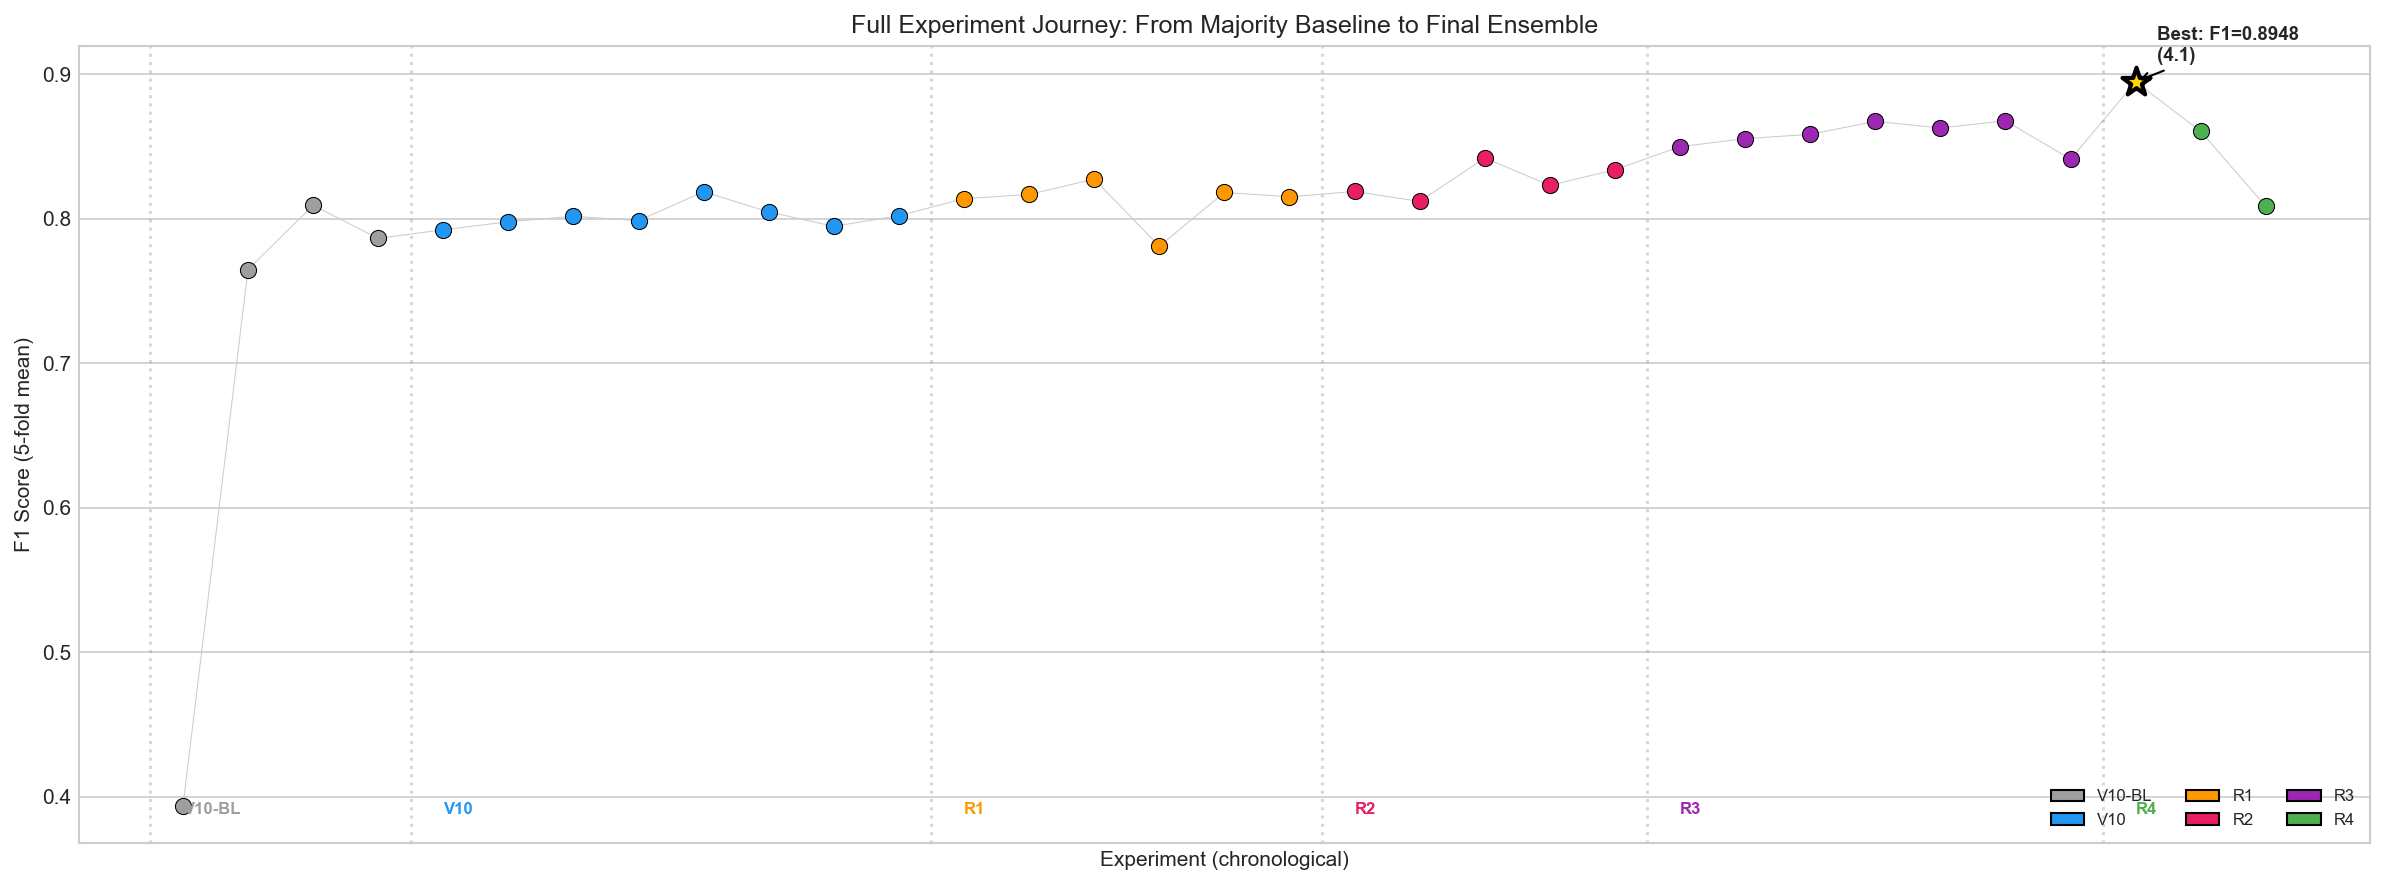

In [6]:
# Plot 2: Full Experiment Journey (Hero Scatter Plot)
all_exps = []

# V10 baselines
v10_baselines = [
    ("Majority", 0.3934), ("LogReg", 0.7648), ("RF", 0.8093), ("XGB-flat", 0.7864),
]
for name, f1 in v10_baselines:
    all_exps.append(("V10-BL", name, f1))

# V10 LSTM/Hybrid
v10_models = [
    ("LSTM-A", 0.7924), ("Hybrid-A", 0.7979),
    ("LSTM-B", 0.8017), ("Hybrid-B", 0.7987),
    ("LSTM-C", 0.8187), ("Hybrid-C", 0.8047),
    ("LSTM-D", 0.7948), ("Hybrid-D", 0.8021),
]
for name, f1 in v10_models:
    all_exps.append(("V10", name, f1))

# R1-R2 experiments (skip grid search rows)
for _, row in exp_log.iterrows():
    eid = str(row["exp_id"])
    if eid.startswith("2.4_a"):
        continue
    phase = "R1" if eid.startswith("1") or eid == "R1_combined" else "R2"
    all_exps.append((phase, eid, float(row["new_f1"])))

# R3 experiments
for _, row in exp_log_r3.iterrows():
    all_exps.append(("R3", str(row["exp_id"]), float(row["new_f1"])))

# R4 experiments
for _, row in exp_log_r4.iterrows():
    all_exps.append(("R4", str(row["exp_id"]), float(row["new_f1"])))

fig, ax = plt.subplots(figsize=(16, 6))

phase_colors = {"V10-BL": "#9E9E9E", "V10": "#2196F3", "R1": "#FF9800",
                "R2": "#E91E63", "R3": "#9C27B0", "R4": "#4CAF50"}

x_positions = range(len(all_exps))
for i, (phase, name, f1) in enumerate(all_exps):
    ax.scatter(i, f1, color=phase_colors[phase], s=60, edgecolors="black", linewidth=0.5, zorder=2)

ax.plot(x_positions, [e[2] for e in all_exps], color="#CCCCCC", linewidth=0.5, zorder=1)

# Highlight best
best_idx = max(range(len(all_exps)), key=lambda i: all_exps[i][2])
ax.scatter(best_idx, all_exps[best_idx][2], color="gold", s=200, edgecolors="black",
           linewidth=2, zorder=3, marker="*")
ax.annotate(f"Best: F1={all_exps[best_idx][2]:.4f}\n({all_exps[best_idx][1]})",
            (best_idx, all_exps[best_idx][2]), textcoords="offset points",
            xytext=(10, 10), fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->"))

# Phase boundaries
phase_starts = {}
for i, (phase, _, _) in enumerate(all_exps):
    if phase not in phase_starts:
        phase_starts[phase] = i
for phase, start in phase_starts.items():
    ax.axvline(x=start - 0.5, color="gray", linestyle=":", alpha=0.3)
    ax.text(start, ax.get_ylim()[0] + 0.02, phase, fontsize=8, fontweight="bold",
            color=phase_colors[phase])

from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=c, edgecolor="black", label=p)
                  for p, c in phase_colors.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, ncol=3)

ax.set_xlabel("Experiment (chronological)")
ax.set_ylabel("F1 Score (5-fold mean)")
ax.set_title("Full Experiment Journey: From Majority Baseline to Final Ensemble")
ax.set_xticks([])

plt.tight_layout()
plt.show()

C:\Users\malho\AppData\Local\Temp\ipykernel_23728\2607911858.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(exp_labels, rotation=15, ha="right", fontsize=8)


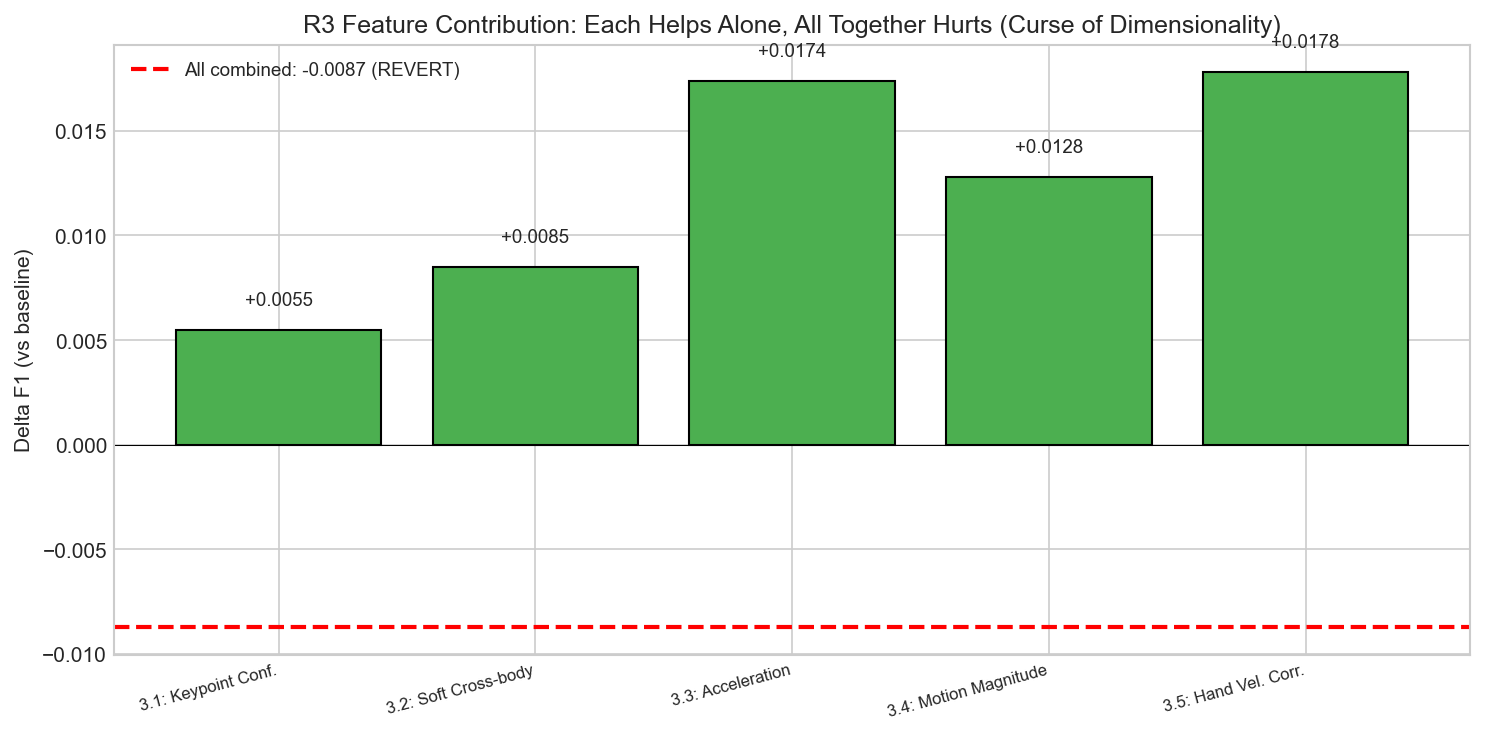

In [7]:
# Plot 3: R3 Feature Contribution (delta-F1 bars)
r3_exps = exp_log_r3[~exp_log_r3["exp_id"].isin(["R12_baseline", "R3_combined"])]

exp_labels = [
    "3.1: Keypoint Conf.",
    "3.2: Soft Cross-body",
    "3.3: Acceleration",
    "3.4: Motion Magnitude",
    "3.5: Hand Vel. Corr.",
]
delta_f1s = [float(row["delta_f1"]) for _, row in r3_exps.iterrows()]

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#4CAF50" if d > 0 else "#F44336" for d in delta_f1s]
bars = ax.bar(exp_labels, delta_f1s, color=bar_colors, edgecolor="black")

for bar, d in zip(bars, delta_f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.001 if d > 0 else -0.003),
            f"{d:+.4f}", ha="center", va="bottom" if d > 0 else "top", fontsize=9)

# Show combined result (REVERT)
r3_combined = exp_log_r3[exp_log_r3["exp_id"] == "R3_combined"]
if not r3_combined.empty:
    combined_delta = float(r3_combined.iloc[0]["delta_f1"])
    ax.axhline(y=combined_delta, color="red", linestyle="--", linewidth=2,
               label=f"All combined: {combined_delta:+.4f} (REVERT)")
    ax.legend(fontsize=9)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_ylabel("Delta F1 (vs baseline)")
ax.set_title("R3 Feature Contribution: Each Helps Alone, All Together Hurts (Curse of Dimensionality)")
ax.set_xticklabels(exp_labels, rotation=15, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

**Key takeaways from 4 rounds of experiments:**

- **Attention pooling** (R1) was the best single architectural change — lets the model focus on the key moment in each clip
- **F1-based early stopping** (R2) outperformed loss-based stopping by +2.7% F1 — optimizing the actual metric matters
- **R3 curse of dimensionality:** each of 5 new feature groups helped individually (+0.6% to +1.8%), but combining all 5 (77->158 dims) hurt performance — dataset too small for the expanded feature space
- **Weighted LSTM+RF ensemble** (R4) gave the biggest single-round jump (+3.1% F1) with the lowest variance — sequential + spatial classifiers are complementary

In [8]:
# V10 Ablation Table
ablation_df = pd.read_csv(RESULTS_DIR / "ablation_table.csv", index_col=0)

print("V10 Ablation: 4 baselines + 4 feature tiers x 2 models = 12 configurations")
display(ablation_df.style)

V10 Ablation: 4 baselines + 4 feature tiers x 2 models = 12 configurations


,Model,Features,accuracy,precision,recall,f1,auc
#,,,,,,,
1,Majority Class,72,0.4715 +/- 0.0225,0.2927 +/- 0.2392,0.6000 +/- 0.4899,0.3934 +/- 0.3214,0.5000 +/- 0.0000
2,Logistic Regression,72,0.7384 +/- 0.0226,0.7062 +/- 0.0367,0.8369 +/- 0.0603,0.7648 +/- 0.0358,0.7347 +/- 0.0211
3,Random Forest,72,0.7934 +/- 0.0600,0.7862 +/- 0.0955,0.8456 +/- 0.0526,0.8093 +/- 0.0486,0.8531 +/- 0.0343
4,XGBoost (flat),72,0.7504 +/- 0.0510,0.7089 +/- 0.0637,0.8937 +/- 0.0729,0.7864 +/- 0.0375,0.8093 +/- 0.0561
5,LSTM Only (Tier A: 36 feat),36,0.7872 +/- 0.0398,0.7864 +/- 0.0548,0.8040 +/- 0.0762,0.7924 +/- 0.0487,0.8031 +/- 0.0538
6,LSTM+XGB (Tier A: 36 feat),36,0.7925 +/- 0.0384,0.7898 +/- 0.0545,0.8124 +/- 0.0806,0.7979 +/- 0.0488,0.8154 +/- 0.0395
7,LSTM Only (Tier B: 72 feat),72,0.7824 +/- 0.0817,0.7726 +/- 0.1043,0.8474 +/- 0.0726,0.8017 +/- 0.0612,0.8033 +/- 0.1010
8,LSTM+XGB (Tier B: 72 feat),72,0.7888 +/- 0.0724,0.7960 +/- 0.0961,0.8083 +/- 0.0410,0.7987 +/- 0.0585,0.8156 +/- 0.0571
9,LSTM Only (Tier C: 77 feat),77,0.8066 +/- 0.0838,0.8029 +/- 0.1094,0.8424 +/- 0.0616,0.8187 +/- 0.0732,0.8133 +/- 0.1067


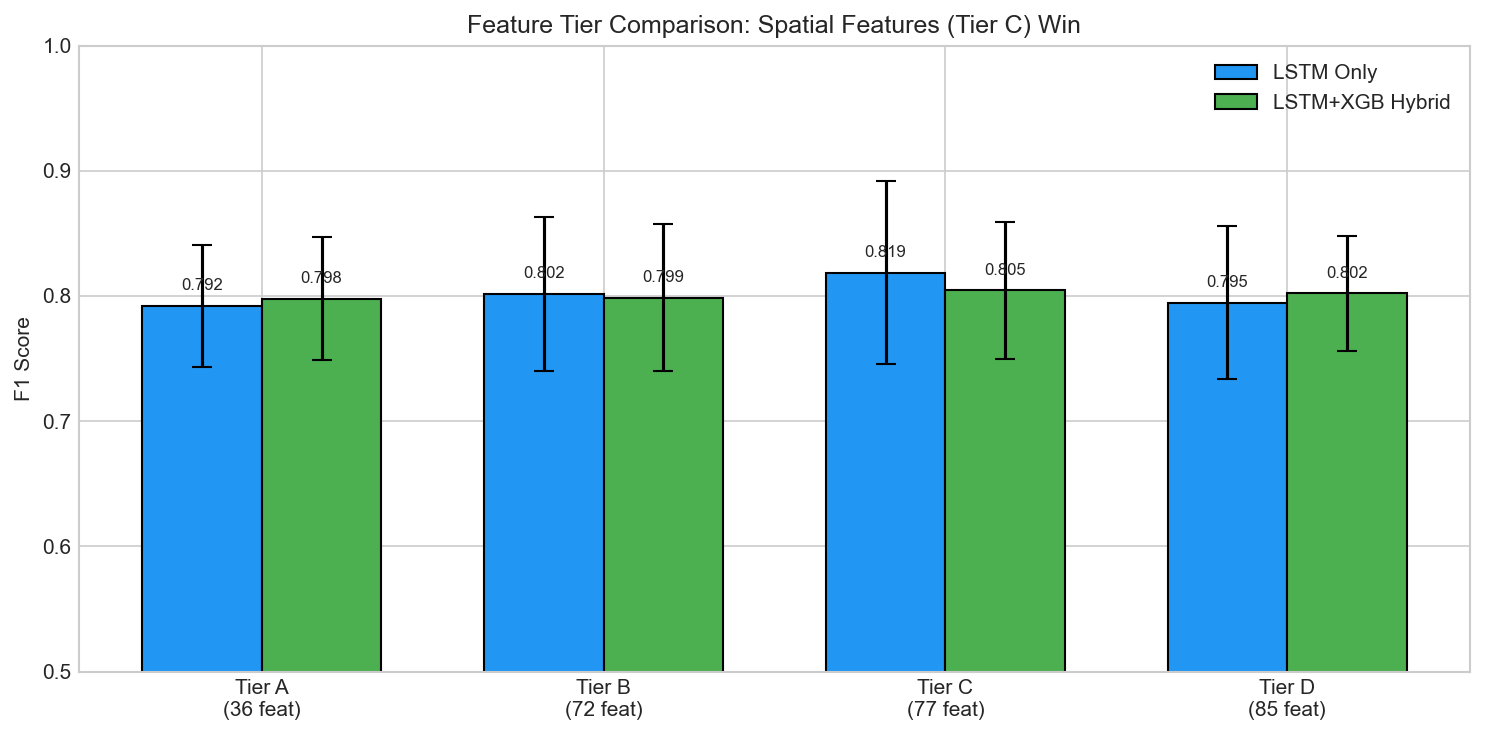

In [9]:
# Plot 4: Feature Tier Comparison (LSTM vs Hybrid)
tier_names = ["A_base", "B_velocity", "C_spatial", "D_full"]
tier_labels = ["Tier A\n(36 feat)", "Tier B\n(72 feat)", "Tier C\n(77 feat)", "Tier D\n(85 feat)"]

lstm_f1_means, lstm_f1_stds = [], []
hyb_f1_means, hyb_f1_stds = [], []

for tier in tier_names:
    lstm_vals = [phase2_results[tier][f]["lstm_metrics"]["f1"] for f in phase2_results[tier]]
    hyb_vals = [phase2_results[tier][f]["hybrid_metrics"]["f1"] for f in phase2_results[tier]]
    lstm_f1_means.append(np.mean(lstm_vals));  lstm_f1_stds.append(np.std(lstm_vals))
    hyb_f1_means.append(np.mean(hyb_vals));    hyb_f1_stds.append(np.std(hyb_vals))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tier_labels))
width = 0.35

bars1 = ax.bar(x - width/2, lstm_f1_means, width, yerr=lstm_f1_stds,
               label="LSTM Only", color="#2196F3", capsize=5, edgecolor="black")
bars2 = ax.bar(x + width/2, hyb_f1_means, width, yerr=hyb_f1_stds,
               label="LSTM+XGB Hybrid", color="#4CAF50", capsize=5, edgecolor="black")

ax.set_ylabel("F1 Score")
ax.set_title("Feature Tier Comparison: Spatial Features (Tier C) Win")
ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.legend()
ax.set_ylim(0.5, 1.0)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f"{height:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

**Ablation findings:** Tier C (spatial features: wrist-to-hip distance, hand height, cross-body
reach) is the most discriminative — these directly capture the concealment gestures that
characterize shoplifting. Tier D overfits: the 8 additional biomechanical features add noise
without enough data to learn robust patterns.

In [10]:
# Grand Summary Table: Milestone Progression
milestones = [
    ("Majority Class", 0.3934, 0.5000, "---"),
    ("Best Baseline (RF)", 0.8093, 0.8531, "---"),
    ("V10 Best (Tier C LSTM)", 0.8187, 0.8133, "V10"),
    ("V11 R1 Combined", 0.8152, 0.8383, "R1"),
    ("V11 R2 Combined", r12_data["best_metrics"]["f1_mean"],
     r12_data["best_metrics"]["auc_mean"], "R2"),
    ("V11 R3 Best (3.5)", r3_data["best_metrics"]["f1_mean"],
     r3_data["best_metrics"]["auc_mean"], "R3"),
    ("V11 R4 Ensemble", r4_data["ensemble_result"]["f1_mean"],
     r4_data["ensemble_result"]["auc_mean"], "R4"),
]

print("Milestone Progression")
print("=" * 70)
print(f"{'Milestone':<30} {'F1':>8} {'AUC':>8} {'Round':>8}")
print("-" * 70)
for name, f1, auc_val, rnd in milestones:
    print(f"{name:<30} {f1:>8.4f} {auc_val:>8.4f} {rnd:>8}")
print("-" * 70)
print(f"{'Total Improvement':<30} {milestones[-1][1] - milestones[0][1]:>+8.4f} "
      f"{milestones[-1][2] - milestones[0][2]:>+8.4f}")

Milestone Progression
Milestone                            F1      AUC    Round
----------------------------------------------------------------------
Majority Class                   0.3934   0.5000      ---
Best Baseline (RF)               0.8093   0.8531      ---
V10 Best (Tier C LSTM)           0.8187   0.8133      V10
V11 R1 Combined                  0.8152   0.8383       R1
V11 R2 Combined                  0.8339   0.8471       R2
V11 R3 Best (3.5)                0.8678   0.8752       R3
V11 R4 Ensemble                  0.8948   0.9195       R4
----------------------------------------------------------------------
Total Improvement               +0.5014  +0.4195


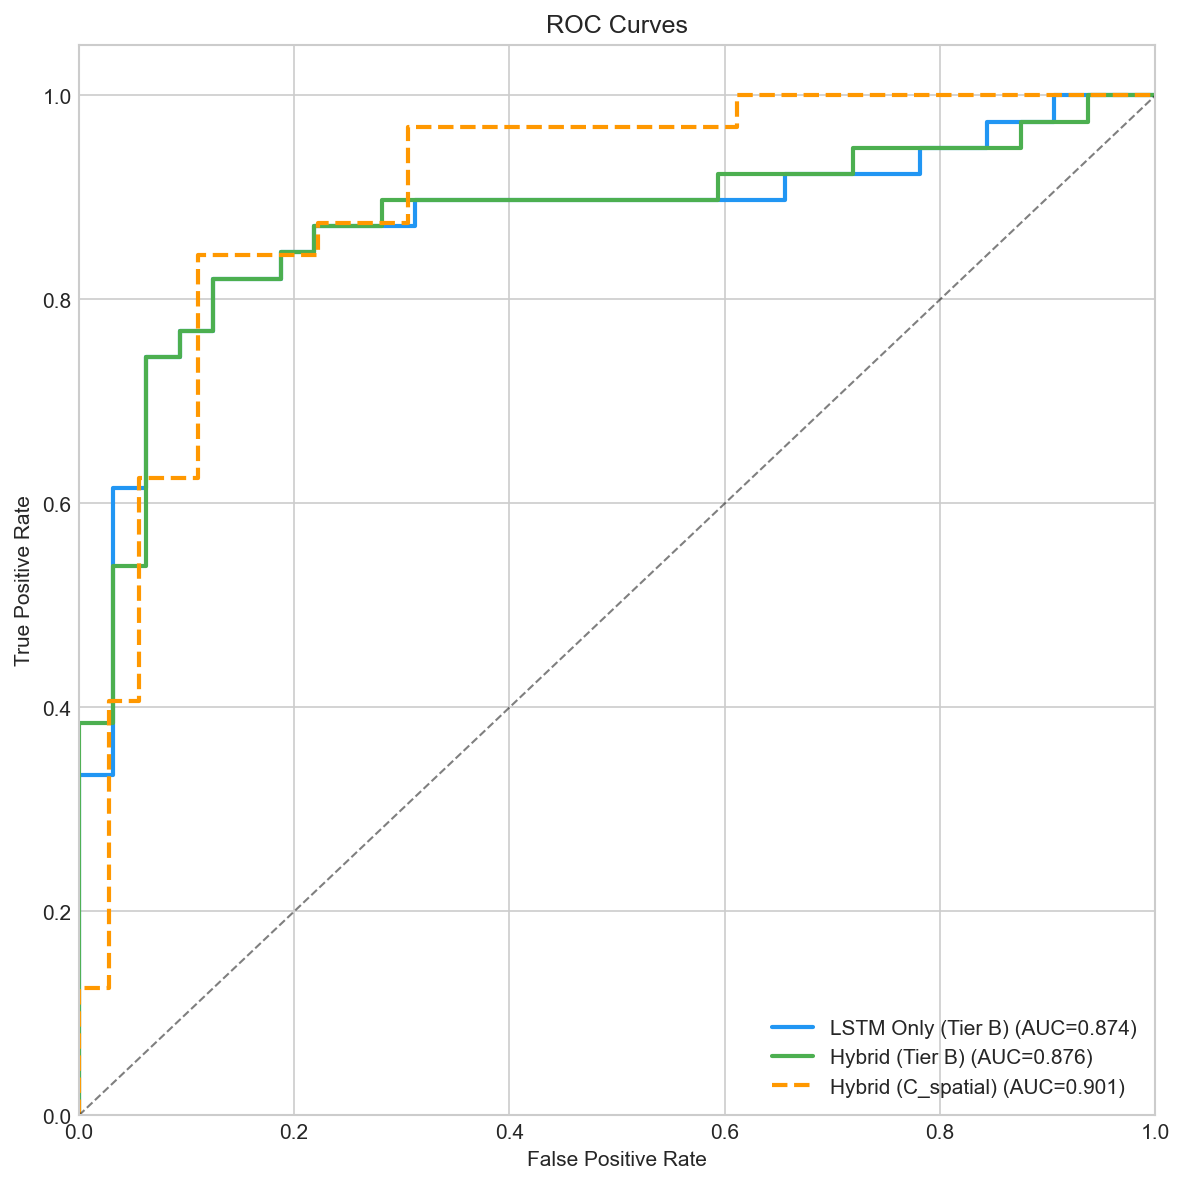

In [11]:
# Plot 5: ROC Curves
from sklearn.metrics import roc_curve, auc, confusion_matrix

fig, ax = plt.subplots(figsize=(8, 8))

tier_names_roc = ["A_base", "B_velocity", "C_spatial", "D_full"]

# Best fold for Tier B hybrid (by AUC)
tier_b = phase2_results["B_velocity"]
best_fold_b = max(tier_b.keys(), key=lambda k: tier_b[k]["hybrid_metrics"]["auc"])

# Best overall tier by mean hybrid AUC
tier_aucs = {}
for tier in tier_names_roc:
    vals = [phase2_results[tier][f]["hybrid_metrics"]["auc"] for f in phase2_results[tier]]
    tier_aucs[tier] = np.mean(vals)
best_tier = max(tier_aucs, key=tier_aucs.get)

curves_to_plot = [
    ("B_velocity", best_fold_b, "LSTM Only (Tier B)", "clip_scores_lstm", "#2196F3", "-"),
    ("B_velocity", best_fold_b, "Hybrid (Tier B)", "clip_scores_xgb", "#4CAF50", "-"),
]
if best_tier != "B_velocity":
    best_fold_other = max(phase2_results[best_tier].keys(),
                          key=lambda k: phase2_results[best_tier][k]["hybrid_metrics"]["auc"])
    curves_to_plot.append(
        (best_tier, best_fold_other, f"Hybrid ({best_tier})", "clip_scores_xgb", "#FF9800", "--")
    )

for tier, fold, label, scores_key, color, ls in curves_to_plot:
    r = phase2_results[tier][fold]
    y_true = np.array(r["clip_labels"])
    y_scores = np.array(r[scores_key])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linestyle=ls, lw=2, label=f"{label} (AUC={roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(loc="lower right")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

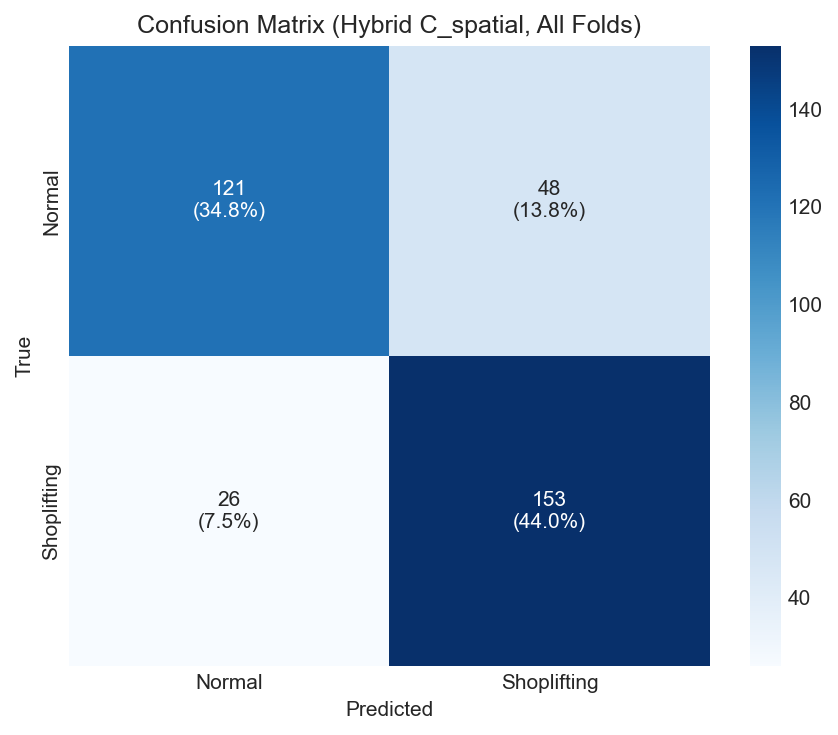

In [12]:
# Plot 6: Confusion Matrix (best tier, all folds aggregated)
best_tier_f1 = max(tier_names_roc, key=lambda t: np.mean(
    [phase2_results[t][f]["hybrid_metrics"]["f1"] for f in phase2_results[t]]))

fig, ax = plt.subplots(figsize=(6, 5))

all_true_cm, all_pred_cm = [], []
for fold in phase2_results[best_tier_f1]:
    r = phase2_results[best_tier_f1][fold]
    for cr in r["clip_results"]:
        all_true_cm.append(cr["true_label"])
        all_pred_cm.append(cr["hybrid_pred"])

cm = confusion_matrix(all_true_cm, all_pred_cm)
total = cm.sum()

annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm[i, j]/total*100:.1f}%)"

sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=ax,
            xticklabels=["Normal", "Shoplifting"],
            yticklabels=["Normal", "Shoplifting"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (Hybrid {best_tier_f1}, All Folds)")
plt.tight_layout()
plt.show()

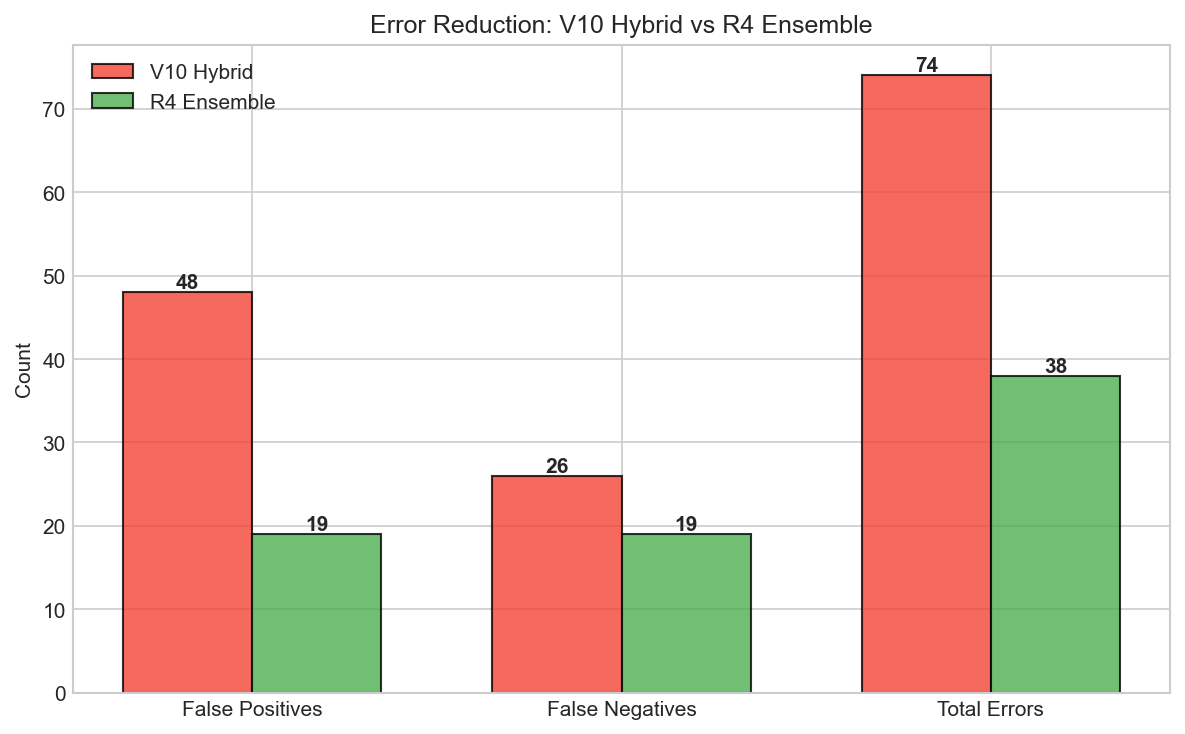

In [13]:
# Plot 7: Error Reduction (V10 vs R4 side-by-side)
v10_fp, v10_fn = 0, 0
for fold in phase2_results[best_tier_f1]:
    r = phase2_results[best_tier_f1][fold]
    for cr in r["clip_results"]:
        if cr["true_label"] == 0 and cr["hybrid_pred"] == 1: v10_fp += 1
        elif cr["true_label"] == 1 and cr["hybrid_pred"] == 0: v10_fn += 1

r4_fp = r4_data["ensemble_result"]["fp_count"]
r4_fn = r4_data["ensemble_result"]["fn_count"]

fig, ax = plt.subplots(figsize=(8, 5))

categories = ["False Positives", "False Negatives", "Total Errors"]
v10_vals = [v10_fp, v10_fn, v10_fp + v10_fn]
r4_vals = [r4_fp, r4_fn, r4_fp + r4_fn]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, v10_vals, width, label="V10 Hybrid", color="#F44336",
               edgecolor="black", alpha=0.8)
bars2 = ax.bar(x + width/2, r4_vals, width, label="R4 Ensemble", color="#4CAF50",
               edgecolor="black", alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", fontweight="bold")

ax.set_ylabel("Count")
ax.set_title("Error Reduction: V10 Hybrid vs R4 Ensemble")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.show()

**Error analysis:** The V10 hybrid produced 74 total errors, biased toward false positives
(48 FP / 26 FN). The R4 ensemble cut this to 38 errors with a balanced 19 FP / 19 FN ratio
— a 49% reduction. Remaining errors stem from subtle concealment, brief actions occupying
few frames, and partial occlusion degrading keypoint quality.

## 5. What Worked / What Didn't

**What worked:**
- Spatial features (wrist-to-hip, cross-body reach) — most discriminative signal for concealment
- Temporal attention — lets the model focus on the key moment, not just the final frame
- F1-based early stopping — optimizing the actual metric beats proxy loss
- Weighted ensemble (LSTM + RF) — sequential + spatial classifiers complement each other
- GroupKFold anti-leakage — prevents inflated scores from scene memorization

**What didn't:**
- LayerNorm before LSTM — disrupted meaningful feature magnitudes
- Label smoothing — too aggressive for balanced binary classification
- Combining all R3 features — curse of dimensionality on small dataset (358 clips)
- Hard negative mining — overfitted to ambiguous clips
- Platt scaling — per-fold threshold optimization already handles calibration

## 6. Limitations & Future Work

**Limitations:**
- 358 clips is small for deep learning (R3 curse of dimensionality is a direct consequence)
- Some clips are staged — model may learn acting-specific patterns
- Single-viewpoint fixed CCTV only; untested on varying angles or moving cameras
- Binary classification only (no multi-class anomaly detection)

**Future work:**
- Graph-based models (ST-GCN/Transformers) for natural joint topology
- Larger real-world dataset with diverse store layouts and techniques
- ONNX export for edge deployment with latency benchmarking
- Attention visualization for explainable predictions
- Multi-camera fusion to handle occlusion

## References

1. Yan et al., "Spatial Temporal Graph Convolutional Networks for Skeleton-Based Action Recognition," *AAAI*, 2018.
2. Shi et al., "Two-Stream Adaptive Graph Convolutional Networks for Skeleton-Based Action Recognition," *CVPR*, 2019.
3. Liu et al., "Disentangling and Unifying Graph Convolutions for Skeleton-Based Action Recognition," *CVPR*, 2020.
4. Sultani et al., "Real-World Anomaly Detection in Surveillance Videos," *CVPR*, 2018.
5. Zhang et al., "ByteTrack: Multi-Object Tracking by Associating Every Detection Box," *ECCV*, 2022.
6. Maji et al., "YOLO-Pose: Enhancing YOLO for Multi Person Pose Estimation Using Object Keypoint Similarity Loss," *CVPR Workshop*, 2022.